# EDA DADA-2000 — Anticipación por ventanas pre-TOA

Notebook diseñado para tu pipeline actual:

```text
DADA2000 (Excel) → generate_training_from_excel.py → training_full.txt
                 → make_balanced_training_txt.py    → training_balanced.txt
                 → make_train_val_split.py          → training_train.txt / training_val.txt
                 → dataset.py                       → X3D-S + GRU
```

La tarea validada aquí es clasificación binaria de ventanas temporales previas al accidente:

- `label=0`: riesgo lejano, ventana lejana al TOA.
- `label=1`: riesgo cercano, ventana cercana al TOA.

Definición esperada (según `make_balanced_training_txt.py`):

```text
label 1: gap_to_toa = TOA - end entre 1 y 20 frames    (positive_horizon=20)
label 0: gap_to_toa = TOA - end entre 101 y 180 frames (gray_zone=80, neg_max=180)
zona gris: 21–100 frames descartada
```

## Estructura del notebook

**Parte 1 — Auditoría del pipeline (DADA2000 → splits)** — Secciones A a E:
justifica las decisiones de diseño del pipeline a partir del Excel original.

**Parte 2 — Auditoría de los splits finales** — Secciones 1 a 15:
verifica que `training_train.txt` y `training_val.txt` tienen las propiedades
esperadas y no contienen fugas ni atajos espurios.


In [6]:
from pathlib import Path
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# =============================
# CONFIGURACIÓN — RUTAS
# =============================
# Splits finales (consumidos por dataset.py)
TRAIN_TXT = Path("/data-fast/data-server/vlopezmo/model/training/training_train.txt")
VAL_TXT   = Path("/data-fast/data-server/vlopezmo/model/training/training_val.txt")

# Archivos intermedios del pipeline
BALANCED_TXT = Path("/data-fast/data-server/vlopezmo/model/training/training_balanced.txt")
FULL_TXT     = Path("/data-fast/data-server/vlopezmo/model/training/training_full.txt")

# Dataset original
EXCEL_PATH = Path("/data-fast/data-server/vlopezmo/DADA2000/dada_text_annotations.xlsx")
DADA_ROOT  = Path("/data-fast/data-server/vlopezmo/DADA2000")

# Opcional para visualizar frames (sección 13).
# Debe contener rutas tipo RGB_ROOT / "49/022" / "0001.png".
RGB_ROOT = None  # ejemplo: Path("/data-fast/data-server/vlopezmo/DADA2000/frames")

# =============================
# CONFIGURACIÓN — HIPERPARÁMETROS DEL PIPELINE
# =============================
# Estos valores deben coincidir con make_balanced_training_txt.py
PIPELINE_WINDOW_LEN            = 64
PIPELINE_STRIDE                = 16
PIPELINE_POSITIVE_HORIZON      = 20
PIPELINE_GRAY_ZONE             = 80
PIPELINE_NEGATIVE_MAX_DISTANCE = 180
PIPELINE_MAX_POS_PER_VIDEO     = 2
PIPELINE_MAX_NEG_PER_VIDEO     = 2

# Derivados (no tocar)
NEGATIVE_MIN_DISTANCE = PIPELINE_POSITIVE_HORIZON + PIPELINE_GRAY_ZONE + 1  # 101
WINDOW_LEN_EXPECTED   = PIPELINE_WINDOW_LEN
STRIDE_EXPECTED       = PIPELINE_STRIDE
POSITIVE_HORIZON      = PIPELINE_POSITIVE_HORIZON
GRAY_ZONE             = PIPELINE_GRAY_ZONE
NEGATIVE_MAX_DISTANCE = PIPELINE_NEGATIVE_MAX_DISTANCE

# =============================
# CONFIGURACIÓN — MODELO
# =============================
NUM_FRAMES_MODEL  = 16
X3D_SUBCLIP_LEN   = 13
X3D_SUBCLIP_STRIDE = 1
FPS_ASSUMED       = 30

# =============================
# COLUMNAS DEL EXCEL
# =============================
EXCEL_ACC_COL = "whether an accident occurred (1/0)"
EXCEL_TOA_COL = "accident frame"

# =============================
# Verificación de rutas
# =============================
print("=== Rutas ===")
print(f"TRAIN_TXT:     {TRAIN_TXT}            exists={TRAIN_TXT.exists()}")
print(f"VAL_TXT:       {VAL_TXT}              exists={VAL_TXT.exists()}")
print(f"BALANCED_TXT:  {BALANCED_TXT}         exists={BALANCED_TXT.exists()}")
print(f"FULL_TXT:      {FULL_TXT}             exists={FULL_TXT.exists()}")
print(f"EXCEL_PATH:    {EXCEL_PATH}           exists={EXCEL_PATH.exists()}")
print(f"DADA_ROOT:     {DADA_ROOT}            exists={DADA_ROOT.exists()}")
print()
print("=== Hiperparámetros pipeline ===")
print(f"window_len={PIPELINE_WINDOW_LEN}, stride={PIPELINE_STRIDE}")
print(f"positive_horizon={PIPELINE_POSITIVE_HORIZON}, gray_zone={PIPELINE_GRAY_ZONE}")
print(f"negative range: [{NEGATIVE_MIN_DISTANCE}, {PIPELINE_NEGATIVE_MAX_DISTANCE}]")
print(f"max_pos_per_video={PIPELINE_MAX_POS_PER_VIDEO}, max_neg_per_video={PIPELINE_MAX_NEG_PER_VIDEO}")

=== Rutas ===
TRAIN_TXT:     /data-fast/data-server/vlopezmo/model/training/training_train.txt            exists=True
VAL_TXT:       /data-fast/data-server/vlopezmo/model/training/training_val.txt              exists=True
BALANCED_TXT:  /data-fast/data-server/vlopezmo/model/training/training_balanced.txt         exists=True
FULL_TXT:      /data-fast/data-server/vlopezmo/model/training/training_full.txt             exists=True
EXCEL_PATH:    /data-fast/data-server/vlopezmo/DADA2000/dada_text_annotations.xlsx           exists=True
DADA_ROOT:     /data-fast/data-server/vlopezmo/DADA2000            exists=True

=== Hiperparámetros pipeline ===
window_len=64, stride=16
positive_horizon=20, gray_zone=80
negative range: [101, 180]
max_pos_per_video=2, max_neg_per_video=2


## Parser de los `.txt` (utilidades)

Formato esperado en todos los `.txt` del pipeline:

```text
video_id label start end toa,description
```

Definimos el parser aquí porque lo usaremos tanto en la auditoría del pipeline
(secciones A-E) como en la auditoría de splits (secciones 1-15).

In [7]:
def parse_training_line(line: str):
    """Parsea una línea del formato: video_id label start end toa,description"""
    raw = line.rstrip("\n")
    if not raw.strip():
        return None
    if "," not in raw:
        raise ValueError(f"Línea sin coma separadora: {raw[:120]}")
    left, description = raw.split(",", 1)
    parts = left.split()
    if len(parts) < 5:
        raise ValueError(f"Cabecera inválida: {left}")
    return {
        "video_id": parts[0],
        "label": int(parts[1]),
        "start": int(parts[2]),
        "end": int(parts[3]),
        "toa": int(parts[4]),
        "description": description.strip(),
        "raw_line": raw,
    }


def enrich_df(df: pd.DataFrame):
    """Añade columnas derivadas útiles para el análisis."""
    if df.empty:
        return df
    df = df.copy()
    df["group_id"] = df["video_id"].astype(str).str.split("/").str[0]
    df["clip_id"] = df["video_id"].astype(str) + "_" + df["start"].astype(str) + "_" + df["end"].astype(str)
    df["window_len"] = df["end"] - df["start"] + 1
    # Para negativos absolutos (toa=0), gap_to_toa no tiene sentido temporal
    df["gap_to_toa"] = df["toa"] - df["end"]
    df["start_to_toa"] = df["toa"] - df["start"]
    df["gap_seconds"] = df["gap_to_toa"] / FPS_ASSUMED
    df["window_seconds"] = df["window_len"] / FPS_ASSUMED
    df["is_pre_toa"] = df["end"] < df["toa"]
    df["is_absolute_negative"] = df["toa"] == 0
    return df


def load_txt(path: Path, split_name: str):
    """Carga un .txt del pipeline. Devuelve DataFrame vacío si no existe."""
    rows = []
    if path is None or not Path(path).exists():
        print(f"[WARN] No existe {path}. Se omite split={split_name}.")
        return pd.DataFrame()
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            if not line.strip():
                continue
            row = parse_training_line(line)
            if row is None:
                continue
            row["source_file"] = str(path)
            row["line_number"] = i
            row["split"] = split_name
            rows.append(row)
    return enrich_df(pd.DataFrame(rows))

---

# PARTE 1 — Auditoría del pipeline (DADA2000 → splits)

Las secciones A a E justifican las decisiones de diseño del pipeline de generación
de muestras. Sin esta parte, los hiperparámetros (`window_len=64`,
`positive_horizon=20`, `gray_zone=80`) aparecen como valores mágicos en la
memoria del TFG. Con esta parte, son decisiones razonadas a partir de la
distribución de TOA y duraciones del dataset original.

## A. Dataset original DADA2000

Cargamos las anotaciones del Excel original y caracterizamos el dataset
de partida antes de cualquier filtrado o procesamiento.

In [8]:
if EXCEL_PATH.exists():
    df_excel = pd.read_excel(EXCEL_PATH, sheet_name="Sheet1", header=0)
    df_excel = df_excel.sort_values(["type", "video"]).reset_index(drop=True)
    df_excel["vid_num"] = df_excel.groupby("type").cumcount() + 1
    df_excel["video_id"] = df_excel["type"].astype(str) + "/" + df_excel["vid_num"].apply(lambda x: f"{x:03d}")

    n_excel_total = len(df_excel)
    n_excel_acc = int((df_excel[EXCEL_ACC_COL] == 1).sum())
    n_excel_no_acc = int((df_excel[EXCEL_ACC_COL] == 0).sum())
    n_excel_acc_valid_toa = int(((df_excel[EXCEL_ACC_COL] == 1) & (df_excel[EXCEL_TOA_COL] > 0)).sum())
    n_excel_acc_invalid_toa = n_excel_acc - n_excel_acc_valid_toa

    excel_summary = pd.DataFrame([
        {"métrica": "vídeos totales en Excel", "valor": n_excel_total},
        {"métrica": "vídeos con accidente (label=1)", "valor": n_excel_acc},
        {"métrica": "vídeos sin accidente (label=0)", "valor": n_excel_no_acc},
        {"métrica": "vídeos con accidente y TOA > 0", "valor": n_excel_acc_valid_toa},
        {"métrica": "vídeos con accidente y TOA inválido", "valor": n_excel_acc_invalid_toa},
        {"métrica": "tipos (categorías) únicos", "valor": df_excel["type"].nunique()},
    ])
    display(excel_summary)
else:
    print(f"[WARN] No existe {EXCEL_PATH}. Las secciones A-E no podrán ejecutarse.")
    df_excel = pd.DataFrame()
    n_excel_total = n_excel_acc = n_excel_no_acc = 0
    n_excel_acc_valid_toa = n_excel_acc_invalid_toa = 0

,métrica,valor
0,vídeos totales en Excel,1962
1,vídeos con accidente (label=1),1945
2,vídeos sin accidente (label=0),17
3,vídeos con accidente y TOA > 0,1945
4,vídeos con accidente y TOA inválido,0
5,tipos (categorías) únicos,52


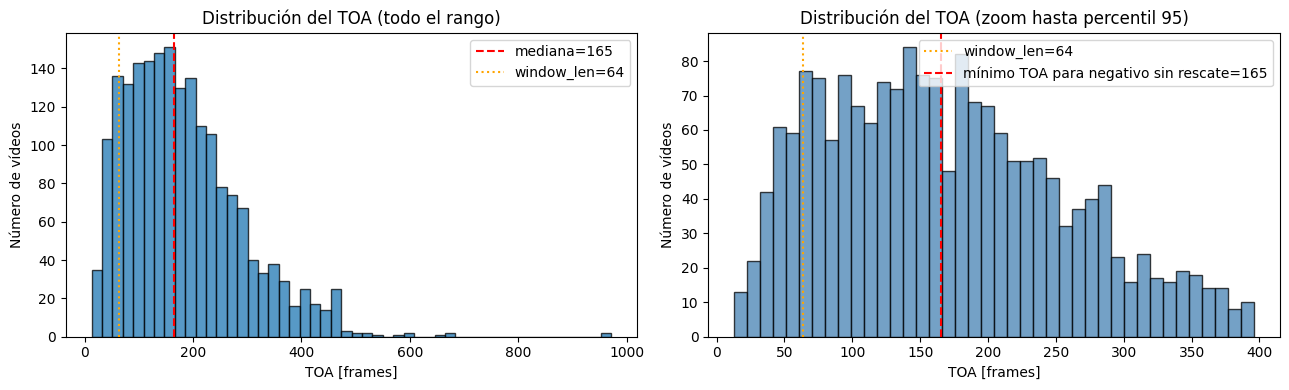

Estadísticas TOA (vídeos con accidente):


,toa
count,1945.00
mean,182.37
std,108.74
min,13.00
25%,100.00
50%,165.00
75%,240.00
max,972.00


In [9]:
# Distribución de TOA en vídeos con accidente
if not df_excel.empty:
    toa_acc = df_excel[(df_excel[EXCEL_ACC_COL] == 1) & (df_excel[EXCEL_TOA_COL] > 0)][EXCEL_TOA_COL]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(toa_acc, bins=50, edgecolor="black", alpha=0.75)
    axes[0].axvline(toa_acc.median(), linestyle="--", color="red", label=f"mediana={toa_acc.median():.0f}")
    axes[0].axvline(PIPELINE_WINDOW_LEN, linestyle=":", color="orange", label=f"window_len={PIPELINE_WINDOW_LEN}")
    axes[0].set_title("Distribución del TOA (todo el rango)")
    axes[0].set_xlabel("TOA [frames]")
    axes[0].set_ylabel("Número de vídeos")
    axes[0].legend()

    # Zoom en el rango más relevante
    toa_zoom = toa_acc[toa_acc <= toa_acc.quantile(0.95)]
    axes[1].hist(toa_zoom, bins=40, edgecolor="black", alpha=0.75, color="steelblue")
    axes[1].axvline(PIPELINE_WINDOW_LEN, linestyle=":", color="orange", label=f"window_len={PIPELINE_WINDOW_LEN}")
    axes[1].axvline(PIPELINE_WINDOW_LEN + NEGATIVE_MIN_DISTANCE, linestyle="--", color="red",
                    label=f"mínimo TOA para negativo sin rescate={PIPELINE_WINDOW_LEN + NEGATIVE_MIN_DISTANCE}")
    axes[1].set_title("Distribución del TOA (zoom hasta percentil 95)")
    axes[1].set_xlabel("TOA [frames]")
    axes[1].set_ylabel("Número de vídeos")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("Estadísticas TOA (vídeos con accidente):")
    display(toa_acc.describe().to_frame("toa").round(2))

In [10]:
# Distribución por escenario (columna 'type' del Excel)
if not df_excel.empty:
    type_counts = df_excel["type"].value_counts()
    print(f"Escenarios únicos en Excel: {len(type_counts)}")
    print(f"Vídeos en top 5 escenarios: {type_counts.head(5).sum()} ({100*type_counts.head(5).sum()/len(df_excel):.1f}%)")
    print()
    print("Top 15 escenarios:")
    display(type_counts.head(15).to_frame("vídeos"))

Escenarios únicos en Excel: 52
Vídeos en top 5 escenarios: 986 (50.3%)

Top 15 escenarios:


,vídeos
11,252
43,209
50,201
10,167
5,157
6,119
37,85
48,82
38,67
8,57


## B. Auditoría de pérdidas en el pipeline

Cuantificamos cuántos vídeos se descartan en cada paso del pipeline:

```text
Excel → training_full.txt → training_balanced.txt → training_train/val.txt
```

Esta tabla es **obligatoria en la memoria del TFG**: justifica de dónde
salen las muestras finales y qué proporción del dataset original sobrevive.

In [11]:
def count_real_frames(video_id):
    """Cuenta frames .png reales en disco para un video_id."""
    img_dir = DADA_ROOT / video_id / "images"
    if not img_dir.exists():
        return None
    return len(list(img_dir.glob("*.png")))


# Esta celda lee disco. Si DADA2000 no está accesible, se salta.
if DADA_ROOT.exists() and not df_excel.empty:
    print("Contando frames reales en disco (puede tardar 1-2 min)...")
    df_excel["real_frames"] = df_excel["video_id"].apply(count_real_frames)
    df_excel["on_disk"] = df_excel["real_frames"].notna()

    n_on_disk = int(df_excel["on_disk"].sum())
    n_off_disk = int((~df_excel["on_disk"]).sum())
    n_too_short = int(((df_excel["real_frames"] < PIPELINE_WINDOW_LEN) & df_excel["on_disk"]).sum())

    print(f"Vídeos en Excel:         {len(df_excel)}")
    print(f"  - encontrados en disco: {n_on_disk}")
    print(f"  - NO encontrados:       {n_off_disk}")
    print(f"  - demasiado cortos (real_frames < {PIPELINE_WINDOW_LEN}): {n_too_short}")
elif df_excel.empty:
    print("[SKIP] Excel no disponible.")
else:
    print(f"[WARN] {DADA_ROOT} no accesible. Saltando análisis de disco.")
    if not df_excel.empty:
        df_excel["real_frames"] = None
        df_excel["on_disk"] = None

Contando frames reales en disco (puede tardar 1-2 min)...
Vídeos en Excel:         1962
  - encontrados en disco: 1911
  - NO encontrados:       51
  - demasiado cortos (real_frames < 64): 1


In [12]:
# Cargar training_full.txt para comparar
full_df = load_txt(FULL_TXT, "full")

if not full_df.empty:
    n_full_total = len(full_df)
    n_full_pos = int((full_df["label"] == 1).sum())
    n_full_neg = int((full_df["label"] == 0).sum())
    n_full_videos = full_df["video_id"].nunique()
    n_full_abs_neg = int(full_df["is_absolute_negative"].sum())
    print(f"training_full.txt: {n_full_total} líneas | {n_full_videos} vídeos únicos")
    print(f"  - positivos: {n_full_pos}")
    print(f"  - negativos: {n_full_neg}")
    print(f"  - de los cuales negativos absolutos (toa=0): {n_full_abs_neg}")
else:
    n_full_total = n_full_pos = n_full_neg = n_full_videos = n_full_abs_neg = 0

training_full.txt: 1795 líneas | 1779 vídeos únicos
  - positivos: 1762
  - negativos: 33
  - de los cuales negativos absolutos (toa=0): 33


In [13]:
# Cargar splits y construir df global (lo reutilizaremos en la Parte 2)
train_df = load_txt(TRAIN_TXT, "train")
val_df = load_txt(VAL_TXT, "val")
df = pd.concat([train_df, val_df], ignore_index=True)

n_balanced = len(df)
n_balanced_pos = int((df["label"] == 1).sum()) if not df.empty else 0
n_balanced_neg = int((df["label"] == 0).sum()) if not df.empty else 0
n_balanced_videos = df["video_id"].nunique() if not df.empty else 0

print(f"\nSplits finales (train + val): {n_balanced} muestras | {n_balanced_videos} vídeos únicos")
print(f"  - positivos: {n_balanced_pos}")
print(f"  - negativos: {n_balanced_neg}")


Splits finales (train + val): 3789 muestras | 1387 vídeos únicos
  - positivos: 1707
  - negativos: 2082


In [14]:
# Tabla de retención paso a paso
retention_rows = [
    {"paso": "1. Excel original", "vídeos": n_excel_total if n_excel_total else "?",
     "muestras": "—", "comentario": "Anotaciones originales DADA2000"},
    {"paso": "2. Con accidente y TOA>0", "vídeos": n_excel_acc_valid_toa if n_excel_acc_valid_toa else "?",
     "muestras": "—",
     "comentario": f"Filtra {n_excel_acc_invalid_toa} vídeos con TOA inválido o ausente"},
    {"paso": "3. Sin accidente", "vídeos": n_excel_no_acc if n_excel_no_acc else "?",
     "muestras": "—", "comentario": "Negativos absolutos potenciales"},
    {"paso": "4. training_full.txt", "vídeos": n_full_videos if n_full_videos else "?",
     "muestras": n_full_total if n_full_total else "?",
     "comentario": (f"{n_full_pos} pos / {n_full_neg} neg "
                    f"({n_full_abs_neg} absolutos)") if n_full_total else "no cargado"},
    {"paso": "5. training_train+val.txt", "vídeos": n_balanced_videos if n_balanced_videos else "?",
     "muestras": n_balanced if n_balanced else "?",
     "comentario": f"{n_balanced_pos} pos / {n_balanced_neg} neg" if n_balanced else "no cargado"},
]
retention_df = pd.DataFrame(retention_rows)
display(retention_df)

# Pérdidas relativas
if n_full_videos and n_excel_total:
    print(f"\nVídeos con accidente perdidos Excel → training_full: "
          f"{n_excel_acc_valid_toa - (n_full_videos - n_full_abs_neg)} "
          f"(razones: no encontrados en disco, frames < window_len, toa > real_frames)")
if n_balanced_videos and n_full_videos:
    perdidos_balanced = n_full_videos - n_balanced_videos
    print(f"Vídeos perdidos training_full → splits: {perdidos_balanced} "
          f"({100*perdidos_balanced/n_full_videos:.1f}% del total)")

,paso,vídeos,muestras,comentario
0,1. Excel original,1962,—,Anotaciones originales DADA2000
1,2. Con accidente y TOA>0,1945,—,Filtra 0 vídeos con TOA inválido o ausente
2,3. Sin accidente,17,—,Negativos absolutos potenciales
3,4. training_full.txt,1779,1795,1762 pos / 33 neg (33 absolutos)
4,5. training_train+val.txt,1387,3789,1707 pos / 2082 neg



Vídeos con accidente perdidos Excel → training_full: 199 (razones: no encontrados en disco, frames < window_len, toa > real_frames)
Vídeos perdidos training_full → splits: 392 (22.0% del total)


## C. Justificación de hiperparámetros del pipeline

Verificamos numéricamente que las decisiones de `window_len=64`,
`positive_horizon=20` y `gray_zone=80` son razonables dada la distribución
real de TOA en el dataset.

**Razonamiento:**
- Para generar al menos un positivo, se necesita: `TOA >= window_len + 1` (con `start=1, end=window_len`, `gap = TOA - end = TOA - 64`, y queremos `gap ∈ [1, 20]`).
- Para generar un negativo sin rescate: `TOA - end >= negative_min_distance`, es decir, `TOA >= window_len + 101 = 165`.
- Si `TOA < 165`, el pipeline activa el **mecanismo de rescate** (reduce dinámicamente la `gray_zone`).

In [15]:
if not df_excel.empty:
    toa_with_acc = df_excel[(df_excel[EXCEL_ACC_COL] == 1) & (df_excel[EXCEL_TOA_COL] > 0)][EXCEL_TOA_COL]

    min_toa_for_pos = PIPELINE_WINDOW_LEN + 1
    min_toa_for_neg_strict = PIPELINE_WINDOW_LEN + NEGATIVE_MIN_DISTANCE

    n_toa_total = len(toa_with_acc)
    n_can_pos = int((toa_with_acc >= min_toa_for_pos).sum())
    n_can_neg_strict = int((toa_with_acc >= min_toa_for_neg_strict).sum())
    n_need_rescue = int(((toa_with_acc >= min_toa_for_pos) & (toa_with_acc < min_toa_for_neg_strict)).sum())
    n_too_short_for_pos = int((toa_with_acc < min_toa_for_pos).sum())

    hp_check = pd.DataFrame([
        {"check": f"vídeos con TOA válido en Excel", "n": n_toa_total, "%": "100.0%"},
        {"check": f"permiten generar positivos (TOA >= {min_toa_for_pos})",
         "n": n_can_pos, "%": f"{100*n_can_pos/n_toa_total:.1f}%"},
        {"check": f"permiten negativos sin rescate (TOA >= {min_toa_for_neg_strict})",
         "n": n_can_neg_strict, "%": f"{100*n_can_neg_strict/n_toa_total:.1f}%"},
        {"check": "activan el mecanismo de rescate (gray_zone reducida)",
         "n": n_need_rescue, "%": f"{100*n_need_rescue/n_toa_total:.1f}%"},
        {"check": f"demasiado cortos para cualquier muestra (TOA < {min_toa_for_pos})",
         "n": n_too_short_for_pos, "%": f"{100*n_too_short_for_pos/n_toa_total:.1f}%"},
    ])
    display(hp_check)

,check,n,%
0,vídeos con TOA válido en Excel,1945,100.0%
1,permiten generar positivos (TOA >= 65),1718,88.3%
2,permiten negativos sin rescate (TOA >= 165),977,50.2%
3,activan el mecanismo de rescate (gray_zone red...,741,38.1%
4,demasiado cortos para cualquier muestra (TOA <...,227,11.7%


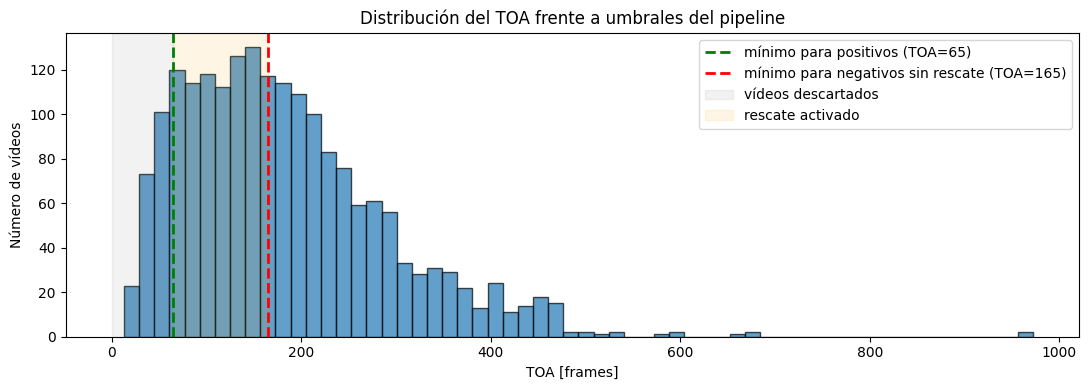

Conclusión:
  - Con window_len=64, el 88.3% de vídeos genera positivos.
  - Solo el 50.2% genera negativos con la gray_zone completa.
  - El 38.1% activa el mecanismo de rescate.
  - El 11.7% se descarta por TOA demasiado bajo.


In [16]:
# Visualización: TOA vs umbrales del pipeline
if not df_excel.empty:
    plt.figure(figsize=(11, 4))
    plt.hist(toa_with_acc, bins=60, edgecolor="black", alpha=0.7)
    plt.axvline(min_toa_for_pos, linestyle="--", color="green", linewidth=2,
                label=f"mínimo para positivos (TOA={min_toa_for_pos})")
    plt.axvline(min_toa_for_neg_strict, linestyle="--", color="red", linewidth=2,
                label=f"mínimo para negativos sin rescate (TOA={min_toa_for_neg_strict})")
    # Zonas
    plt.axvspan(0, min_toa_for_pos, alpha=0.1, color="gray", label="vídeos descartados")
    plt.axvspan(min_toa_for_pos, min_toa_for_neg_strict, alpha=0.1, color="orange",
                label="rescate activado")
    plt.title("Distribución del TOA frente a umbrales del pipeline")
    plt.xlabel("TOA [frames]")
    plt.ylabel("Número de vídeos")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    print("Conclusión:")
    print(f"  - Con window_len={PIPELINE_WINDOW_LEN}, el {100*n_can_pos/n_toa_total:.1f}% de vídeos genera positivos.")
    print(f"  - Solo el {100*n_can_neg_strict/n_toa_total:.1f}% genera negativos con la gray_zone completa.")
    print(f"  - El {100*n_need_rescue/n_toa_total:.1f}% activa el mecanismo de rescate.")
    print(f"  - El {100*n_too_short_for_pos/n_toa_total:.1f}% se descarta por TOA demasiado bajo.")

## D. Auditoría del mecanismo de rescate y fallback

El script `make_balanced_training_txt.py` incluye dos mecanismos para vídeos cortos:

1. **Rescate**: reduce dinámicamente la `gray_zone` cuando el TOA es pequeño,
   permitiendo generar negativos más cercanos al positive_horizon.
2. **Fallback**: si tras el rescate el vídeo aún no tiene negativos, añade una
   ventana fija con `start=1, end=window_len` (los primeros 64 frames del vídeo).

**Esta sección es crítica.** Si muchos negativos son fallbacks con `start=1`,
el modelo podría aprender a separar clases por la posición temporal en el vídeo
en vez de por contenido visual — la correlación espuria que invalidó
experimentos anteriores.

In [17]:
# Detectar muestras del fallback: negativos con start=1, end=window_len exactamente
if not df.empty:
    fallback_mask = (df["label"] == 0) & (df["start"] == 1) & (df["end"] == PIPELINE_WINDOW_LEN) & (~df["is_absolute_negative"])
    n_fallback = int(fallback_mask.sum())
    n_total_neg = int((df["label"] == 0).sum())
    n_abs_neg = int(df["is_absolute_negative"].sum())
    n_sliding_neg = n_total_neg - n_abs_neg

    fallback_summary = pd.DataFrame([
        {"tipo de negativo": "negativos absolutos (vídeos sin accidente, toa=0)",
         "n": n_abs_neg, "%": f"{100*n_abs_neg/n_total_neg:.1f}%" if n_total_neg else "0%"},
        {"tipo de negativo": f"negativos sliding (toa>0, generados por sliding window)",
         "n": n_sliding_neg - n_fallback, "%": f"{100*(n_sliding_neg-n_fallback)/n_total_neg:.1f}%" if n_total_neg else "0%"},
        {"tipo de negativo": f"negativos FALLBACK (start=1, end={PIPELINE_WINDOW_LEN})",
         "n": n_fallback, "%": f"{100*n_fallback/n_total_neg:.1f}%" if n_total_neg else "0%"},
        {"tipo de negativo": "TOTAL negativos", "n": n_total_neg, "%": "100.0%"},
    ])
    display(fallback_summary)

    print(f"\nFallback como % del total de muestras: {100*n_fallback/len(df):.1f}%")

,tipo de negativo,n,%
0,"negativos absolutos (vídeos sin accidente, toa=0)",33,1.6%
1,"negativos sliding (toa>0, generados por slidin...",1189,57.1%
2,"negativos FALLBACK (start=1, end=64)",860,41.3%
3,TOTAL negativos,2082,100.0%



Fallback como % del total de muestras: 22.7%


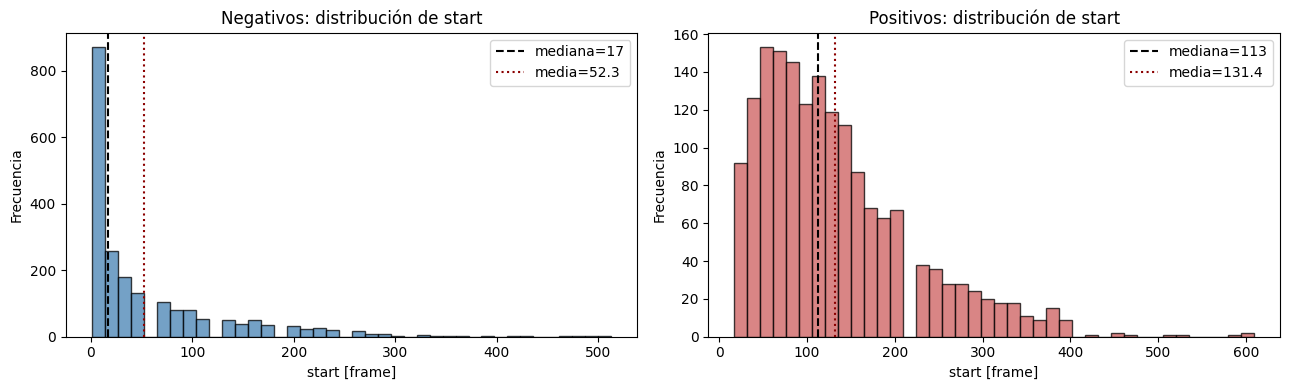

Estadísticas de start por clase:


,count,min,max,mean,median
label 0 (lejano),2082,1,513,52.31,17.0
label 1 (cercano),1707,17,609,131.38,113.0


In [18]:
# Distribución de starts: negativos vs positivos
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, label, name, color in [(axes[0], 0, "Negativos", "steelblue"),
                                    (axes[1], 1, "Positivos", "indianred")]:
        starts = df[df["label"] == label]["start"]
        if len(starts) > 0:
            ax.hist(starts, bins=40, edgecolor="black", alpha=0.75, color=color)
            ax.axvline(starts.median(), linestyle="--", color="black",
                       label=f"mediana={starts.median():.0f}")
            ax.axvline(starts.mean(), linestyle=":", color="darkred",
                       label=f"media={starts.mean():.1f}")
        ax.set_title(f"{name}: distribución de start")
        ax.set_xlabel("start [frame]")
        ax.set_ylabel("Frecuencia")
        ax.legend()
    plt.tight_layout()
    plt.show()

    # Estadísticas comparativas
    stats_start = df.groupby("label")["start"].agg(["count", "min", "max", "mean", "median"]).round(2)
    stats_start.index = ["label 0 (lejano)", "label 1 (cercano)"]
    print("Estadísticas de start por clase:")
    display(stats_start)

In [19]:
# TEST CRÍTICO: ¿puede un modelo trivial separar las clases solo con 'start'?
# Este test detecta correlaciones espurias que invalidarían los experimentos.
if not df.empty:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, average_precision_score

    train_mask = df["split"] == "train"
    val_mask = df["split"] == "val"

    if train_mask.sum() > 0 and val_mask.sum() > 0:
        X_train_trivial = df.loc[train_mask, "start"].values.reshape(-1, 1)
        y_train_trivial = df.loc[train_mask, "label"].values
        X_val_trivial = df.loc[val_mask, "start"].values.reshape(-1, 1)
        y_val_trivial = df.loc[val_mask, "label"].values

        clf_trivial = LogisticRegression(max_iter=1000)
        clf_trivial.fit(X_train_trivial, y_train_trivial)
        probs_val = clf_trivial.predict_proba(X_val_trivial)[:, 1]

        trivial_auc = roc_auc_score(y_val_trivial, probs_val)
        trivial_ap = average_precision_score(y_val_trivial, probs_val)

        print("=" * 65)
        print("TEST DE CORRELACIÓN ESPURIA start ↔ label")
        print("=" * 65)
        print(f"Modelo trivial (regresión logística solo sobre 'start'):")
        print(f"  val_AUC = {trivial_auc:.4f}")
        print(f"  val_AP  = {trivial_ap:.4f}")
        print(f"  baseline AUC aleatorio = 0.5")
        print(f"  baseline AP (proporción positivos en val) = {y_val_trivial.mean():.4f}")
        print()
        print("Interpretación:")
        if trivial_auc < 0.55:
            print("  ✅ AUC < 0.55: no hay correlación espuria significativa.")
            print("     El modelo de visión NO puede tomar atajos basados en el frame inicial.")
            print("     Los splits son seguros para entrenar.")
        elif trivial_auc < 0.65:
            print("  ⚠️  AUC entre 0.55 y 0.65: correlación moderada.")
            print("     Reportar como limitación en la memoria del TFG.")
            print("     Comparar este AUC con el del modelo real para juzgar si aprende contenido visual.")
        else:
            print("  ❌ AUC >= 0.65: correlación FUERTE entre start y label.")
            print("     Los splits podrían permitir atajos espurios.")
            print("     ACCIÓN: revisar el balanceo en make_balanced_training_txt.py")
            print("     antes de defender resultados experimentales.")
    else:
        print("[WARN] Falta train o val. No se puede ejecutar el test.")
        trivial_auc = trivial_ap = None
else:
    trivial_auc = trivial_ap = None

TEST DE CORRELACIÓN ESPURIA start ↔ label
Modelo trivial (regresión logística solo sobre 'start'):
  val_AUC = 0.8260
  val_AP  = 0.7227
  baseline AUC aleatorio = 0.5
  baseline AP (proporción positivos en val) = 0.4430

Interpretación:
  ❌ AUC >= 0.65: correlación FUERTE entre start y label.
     Los splits podrían permitir atajos espurios.
     ACCIÓN: revisar el balanceo en make_balanced_training_txt.py
     antes de defender resultados experimentales.


## E. Conclusiones del pipeline (para la memoria)

Resumen ejecutivo de la auditoría del pipeline. Esta tabla y estos
estadísticos son los que defenderás en la sección "Construcción del dataset"
de la memoria del TFG.

In [20]:
print("=" * 65)
print("RESUMEN PIPELINE DADA2000 → SPLITS")
print("=" * 65)
print()

if n_excel_total:
    print(f"Dataset original (Excel):")
    print(f"  - {n_excel_total} vídeos totales")
    print(f"  - {n_excel_acc_valid_toa} con accidente y TOA válido")
    print(f"  - {n_excel_no_acc} sin accidente")
    print()

if n_balanced:
    print(f"Tras pipeline → splits finales:")
    print(f"  - {n_balanced_videos} vídeos únicos")
    print(f"  - {n_balanced} muestras totales ({n_balanced_pos} pos / {n_balanced_neg} neg)")
    if n_excel_total:
        print(f"  - retención: {100*n_balanced_videos/n_excel_total:.1f}% de vídeos del Excel original")
    print()

if not df_excel.empty:
    print(f"Decisiones de diseño justificadas por los datos:")
    print(f"  - window_len={PIPELINE_WINDOW_LEN}: el {100*n_can_pos/n_toa_total:.1f}% de vídeos permite generar positivos")
    print(f"  - positive_horizon={PIPELINE_POSITIVE_HORIZON}, gray_zone={PIPELINE_GRAY_ZONE}: separación temporal entre clases")
    print(f"  - {100*n_need_rescue/n_toa_total:.1f}% de vídeos requiere mecanismo de rescate")
    print()

if not df.empty:
    print(f"Composición de los negativos:")
    print(f"  - absolutos (vídeos sin accidente): {n_abs_neg} ({100*n_abs_neg/n_total_neg:.1f}%)")
    print(f"  - sliding window: {n_sliding_neg - n_fallback} ({100*(n_sliding_neg-n_fallback)/n_total_neg:.1f}%)")
    print(f"  - fallback (start=1): {n_fallback} ({100*n_fallback/n_total_neg:.1f}%)")
    print()

if trivial_auc is not None:
    print(f"Validación de ausencia de atajos:")
    print(f"  - AUC del modelo trivial (solo 'start'): {trivial_auc:.4f}")
    if trivial_auc < 0.55:
        print(f"  - ✅ El modelo de visión no puede aprender atajos espurios.")
    elif trivial_auc < 0.65:
        print(f"  - ⚠️  Correlación moderada — reportar como limitación.")
    else:
        print(f"  - ❌ Correlación fuerte — REVISAR antes de defender.")
print()
print("=" * 65)

RESUMEN PIPELINE DADA2000 → SPLITS

Dataset original (Excel):
  - 1962 vídeos totales
  - 1945 con accidente y TOA válido
  - 17 sin accidente

Tras pipeline → splits finales:
  - 1387 vídeos únicos
  - 3789 muestras totales (1707 pos / 2082 neg)
  - retención: 70.7% de vídeos del Excel original

Decisiones de diseño justificadas por los datos:
  - window_len=64: el 88.3% de vídeos permite generar positivos
  - positive_horizon=20, gray_zone=80: separación temporal entre clases
  - 38.1% de vídeos requiere mecanismo de rescate

Composición de los negativos:
  - absolutos (vídeos sin accidente): 33 (1.6%)
  - sliding window: 1189 (57.1%)
  - fallback (start=1): 860 (41.3%)

Validación de ausencia de atajos:
  - AUC del modelo trivial (solo 'start'): 0.8260
  - ❌ Correlación fuerte — REVISAR antes de defender.



---

# PARTE 2 — Auditoría de los splits finales

Las secciones 1 a 15 verifican que `training_train.txt` y `training_val.txt`
tienen las propiedades esperadas: integridad temporal, ausencia de fuga entre
splits, distribución de clases coherente, y representatividad de escenarios.

## 1. Carga de los splits

Los splits ya se cargaron en la sección B (necesarios para la auditoría del
pipeline). Aquí solo confirmamos su contenido.

In [21]:
if df.empty:
    # Por si la sección B se saltó, recargar
    train_df = load_txt(TRAIN_TXT, "train")
    val_df = load_txt(VAL_TXT, "val")
    df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Filas cargadas: {len(df)}")
print(f"  - train: {len(train_df)}")
print(f"  - val:   {len(val_df)}")
display(df.head())

Filas cargadas: 3789
  - train: 3035
  - val:   754


,video_id,label,start,end,toa,description,raw_line,source_file,line_number,split,group_id,clip_id,window_len,gap_to_toa,start_to_toa,gap_seconds,window_seconds,is_pre_toa,is_absolute_negative
0,23/001,0,1,64,170,a vehicle is out of control,"23/001 0 1 64 170,a vehicle is out of control",/data-fast/data-server/vlopezmo/model/training...,1,train,23,23/001_1_64,64,106,169,3.533333,2.133333,True,False
1,23/001,1,97,160,170,a vehicle is out of control,"23/001 1 97 160 170,a vehicle is out of control",/data-fast/data-server/vlopezmo/model/training...,2,train,23,23/001_97_160,64,10,73,0.333333,2.133333,True,False
2,10/005,0,161,224,356,ego-car goes straight crossing paths at non-si...,"10/005 0 161 224 356,ego-car goes straight cro...",/data-fast/data-server/vlopezmo/model/training...,3,train,10,10/005_161_224,64,132,195,4.400000,2.133333,True,False
3,10/005,0,129,192,356,ego-car goes straight crossing paths at non-si...,"10/005 0 129 192 356,ego-car goes straight cro...",/data-fast/data-server/vlopezmo/model/training...,4,train,10,10/005_129_192,64,164,227,5.466667,2.133333,True,False
4,10/005,1,273,336,356,ego-car goes straight crossing paths at non-si...,"10/005 1 273 336 356,ego-car goes straight cro...",/data-fast/data-server/vlopezmo/model/training...,5,train,10,10/005_273_336,64,20,83,0.666667,2.133333,True,False


## 2. Resumen ejecutivo del dataset final

Tabla inicial para la memoria: muestras, vídeos únicos, balance de labels y gaps.

In [22]:
def split_summary(df):
    if df.empty:
        return pd.DataFrame()
    rows = []
    for split, g in df.groupby("split"):
        n = len(g)
        c0 = int((g["label"] == 0).sum())
        c1 = int((g["label"] == 1).sum())
        # gap medio solo de muestras pre-TOA reales (excluir absolutos)
        g_pre = g[~g["is_absolute_negative"]]
        rows.append({
            "split": split,
            "samples": n,
            "unique_videos": g["video_id"].nunique(),
            "unique_groups": g["group_id"].nunique(),
            "label_0_far": c0,
            "label_1_near": c1,
            "positive_rate": c1 / n if n else np.nan,
            "abs_negatives": int(g["is_absolute_negative"].sum()),
            "mean_gap_pre_toa": g_pre["gap_to_toa"].mean() if len(g_pre) else np.nan,
            "median_gap_pre_toa": g_pre["gap_to_toa"].median() if len(g_pre) else np.nan,
        })
    rows.append({
        "split": "total",
        "samples": len(df),
        "unique_videos": df["video_id"].nunique(),
        "unique_groups": df["group_id"].nunique(),
        "label_0_far": int((df["label"] == 0).sum()),
        "label_1_near": int((df["label"] == 1).sum()),
        "positive_rate": (df["label"] == 1).mean(),
        "abs_negatives": int(df["is_absolute_negative"].sum()),
        "mean_gap_pre_toa": df[~df["is_absolute_negative"]]["gap_to_toa"].mean(),
        "median_gap_pre_toa": df[~df["is_absolute_negative"]]["gap_to_toa"].median(),
    })
    return pd.DataFrame(rows)

summary = split_summary(df)
display(summary)

,split,samples,unique_videos,unique_groups,label_0_far,label_1_near,positive_rate,abs_negatives,mean_gap_pre_toa,median_gap_pre_toa
0,train,3035,1110,50,1662,1373,0.452389,22,68.136409,56.0
1,val,754,277,38,420,334,0.442971,11,69.818304,60.0
2,total,3789,1387,51,2082,1707,0.450515,33,68.469116,56.0


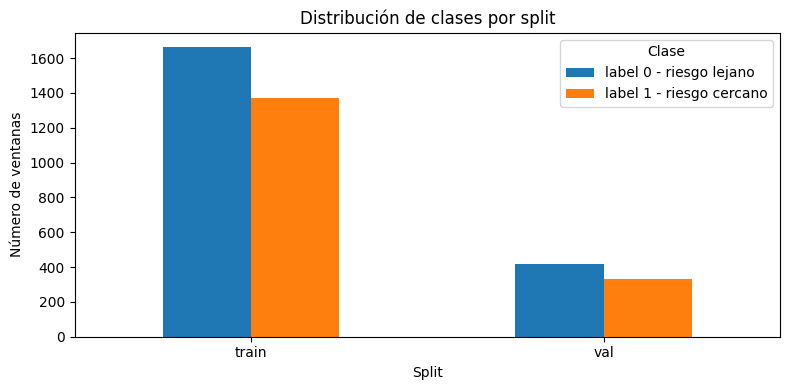

In [23]:
if not df.empty:
    counts = (df.groupby(["split", "label"]).size()
                .unstack(fill_value=0)
                .rename(columns={0: "label 0 - riesgo lejano", 1: "label 1 - riesgo cercano"}))
    ax = counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("Distribución de clases por split")
    ax.set_xlabel("Split")
    ax.set_ylabel("Número de ventanas")
    ax.legend(title="Clase")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 3. Auditoría temporal: ¿todas las ventanas son pre-TOA?

Condición necesaria para poder defender anticipación:

```text
end < TOA  (excepto en negativos absolutos donde toa=0)
```

Además, los labels deben respetar los rangos generados por `make_balanced_training_txt.py`.

**Nota sobre rangos esperados**: usamos los hiperparámetros del pipeline
declarados al inicio del notebook. Las muestras del **mecanismo de rescate**
pueden tener gaps fuera del rango estricto `[101, 180]` — esto es esperado
y se cuantifica aquí.

In [24]:
if not df.empty:
    # Excluir negativos absolutos de los checks que dependen de TOA
    df_pre = df[~df["is_absolute_negative"]].copy()

    bad_post_toa = df_pre[df_pre["end"] >= df_pre["toa"]]
    bad_len = df[df["window_len"] != WINDOW_LEN_EXPECTED]
    bad_start_end = df[df["end"] < df["start"]]
    bad_labels = df[~df["label"].isin([0, 1])]

    bad_pos = df_pre[(df_pre["label"] == 1) & ~df_pre["gap_to_toa"].between(1, POSITIVE_HORIZON)]
    bad_neg_strict = df_pre[(df_pre["label"] == 0) & ~df_pre["gap_to_toa"].between(NEGATIVE_MIN_DISTANCE, NEGATIVE_MAX_DISTANCE)]
    gray_zone_rows = df_pre[df_pre["gap_to_toa"].between(POSITIVE_HORIZON + 1, NEGATIVE_MIN_DISTANCE - 1)]

    # Negativos del rescate: están fuera del rango estricto pero son legítimos
    # Detectamos los que están entre positive_horizon+1 y NEGATIVE_MIN_DISTANCE-1
    rescued_neg = df_pre[(df_pre["label"] == 0) &
                          (df_pre["gap_to_toa"] > POSITIVE_HORIZON) &
                          (df_pre["gap_to_toa"] < NEGATIVE_MIN_DISTANCE)]

    checks_df = pd.DataFrame([
        {"check": "end >= TOA (en muestras pre-TOA)", "bad_rows": len(bad_post_toa), "expected": 0},
        {"check": f"window_len != {WINDOW_LEN_EXPECTED}", "bad_rows": len(bad_len), "expected": 0},
        {"check": "end < start", "bad_rows": len(bad_start_end), "expected": 0},
        {"check": "label not in {0,1}", "bad_rows": len(bad_labels), "expected": 0},
        {"check": f"label 1 fuera de gap [1, {POSITIVE_HORIZON}]", "bad_rows": len(bad_pos), "expected": 0},
        {"check": f"label 0 fuera de gap [{NEGATIVE_MIN_DISTANCE}, {NEGATIVE_MAX_DISTANCE}] (estricto)",
         "bad_rows": len(bad_neg_strict), "expected": "rescate o fallback"},
        {"check": f"  └── de los cuales son rescate (gap [{POSITIVE_HORIZON+1}, {NEGATIVE_MIN_DISTANCE-1}])",
         "bad_rows": len(rescued_neg), "expected": "permitido por diseño"},
        {"check": f"filas en zona gris para POSITIVOS (no debe haber)",
         "bad_rows": len(df_pre[(df_pre["label"] == 1) & df_pre["gap_to_toa"].between(POSITIVE_HORIZON+1, NEGATIVE_MIN_DISTANCE-1)]),
         "expected": 0},
    ])

    def check_status(row):
        if row["expected"] == 0:
            return "OK" if row["bad_rows"] == 0 else "REVISAR"
        else:
            return "INFO"
    checks_df["status"] = checks_df.apply(check_status, axis=1)
    display(checks_df)

    if len(bad_post_toa):
        print("Muestras con end >= TOA (problema crítico):")
        display(bad_post_toa.head(10))
    if len(bad_pos):
        print("Positivos fuera de rango (problema crítico):")
        display(bad_pos.head(10))

,check,bad_rows,expected,status
0,end >= TOA (en muestras pre-TOA),0,0,OK
1,window_len != 64,0,0,OK
2,end < start,0,0,OK
3,"label not in {0,1}",0,0,OK
4,"label 1 fuera de gap [1, 20]",0,0,OK
5,"label 0 fuera de gap [101, 180] (estricto)",495,rescate o fallback,INFO
6,"└── de los cuales son rescate (gap [21, 100])",495,permitido por diseño,INFO
7,filas en zona gris para POSITIVOS (no debe haber),0,0,OK


## 4. Distribución de `gap_to_toa`

La gráfica más importante del EDA:

```text
gap_to_toa = TOA - end
```

Debe separar label 1 como riesgo cercano y label 0 como riesgo lejano.
Excluimos los negativos absolutos (toa=0) porque su gap no tiene sentido temporal.

In [25]:
if not df.empty:
    df_pre = df[~df["is_absolute_negative"]]
    stats_gap = df_pre.groupby(["split", "label"])["gap_to_toa"].agg(
        count="count",
        min="min",
        q25=lambda x: x.quantile(0.25),
        median="median",
        mean="mean",
        q75=lambda x: x.quantile(0.75),
        max="max",
    ).reset_index()
    display(stats_gap)

,split,label,count,min,q25,median,mean,q75,max
0,train,0,1640,31,101.0,119.0,116.332317,142.0,180
1,train,1,1373,1,6.0,10.0,10.568099,16.0,20
2,val,0,409,31,104.0,120.0,118.039120,142.0,180
3,val,1,334,1,6.0,11.0,10.769461,16.0,20


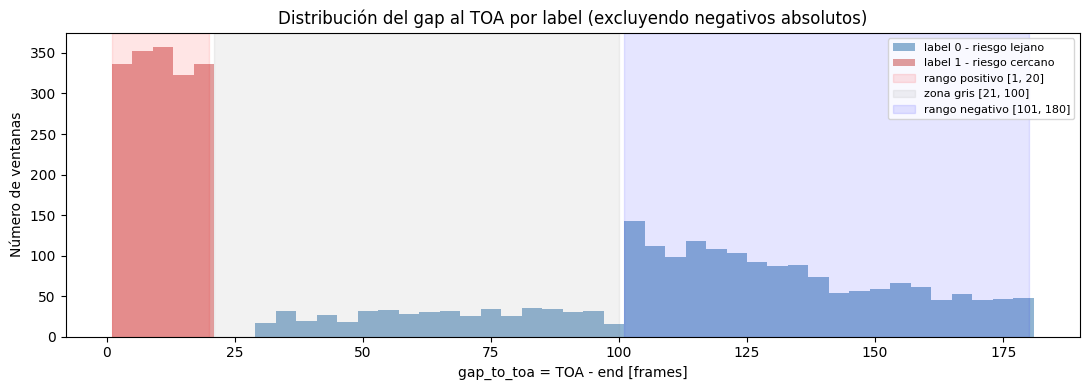

In [26]:
if not df.empty:
    df_pre = df[~df["is_absolute_negative"]]
    plt.figure(figsize=(11, 4))
    for label, label_name, color in [(0, "label 0 - riesgo lejano", "steelblue"),
                                      (1, "label 1 - riesgo cercano", "indianred")]:
        subset = df_pre[df_pre["label"] == label]["gap_to_toa"]
        if len(subset) > 0:
            plt.hist(subset,
                     bins=range(int(df_pre["gap_to_toa"].min()), int(df_pre["gap_to_toa"].max()) + 2, 4),
                     alpha=0.6, label=label_name, color=color)
    plt.axvspan(1, POSITIVE_HORIZON, alpha=0.1, color="red", label=f"rango positivo [1, {POSITIVE_HORIZON}]")
    plt.axvspan(POSITIVE_HORIZON + 1, NEGATIVE_MIN_DISTANCE - 1, alpha=0.1, color="gray",
                label=f"zona gris [{POSITIVE_HORIZON+1}, {NEGATIVE_MIN_DISTANCE-1}]")
    plt.axvspan(NEGATIVE_MIN_DISTANCE, NEGATIVE_MAX_DISTANCE, alpha=0.1, color="blue",
                label=f"rango negativo [{NEGATIVE_MIN_DISTANCE}, {NEGATIVE_MAX_DISTANCE}]")
    plt.title("Distribución del gap al TOA por label (excluyendo negativos absolutos)")
    plt.xlabel("gap_to_toa = TOA - end [frames]")
    plt.ylabel("Número de ventanas")
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

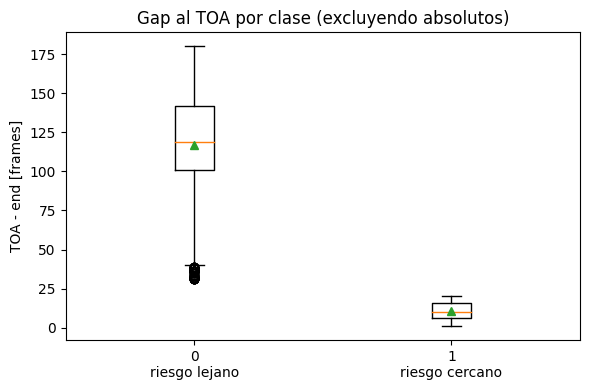

In [27]:
if not df.empty:
    df_pre = df[~df["is_absolute_negative"]]
    if len(df_pre[df_pre["label"] == 0]) > 0 and len(df_pre[df_pre["label"] == 1]) > 0:
        labels_box = ["0\nriesgo lejano", "1\nriesgo cercano"]
        data_box = [df_pre[df_pre["label"] == 0]["gap_to_toa"],
                    df_pre[df_pre["label"] == 1]["gap_to_toa"]]
        plt.figure(figsize=(6, 4))
        plt.boxplot(data_box, labels=labels_box, showmeans=True)
        plt.title("Gap al TOA por clase (excluyendo absolutos)")
        plt.ylabel("TOA - end [frames]")
        plt.tight_layout()
        plt.show()

## 5. Validación del split: fuga train/validation

Debe ser 0:

```text
vídeos compartidos entre train y validation = 0
```

También verificamos solapamiento por `group_id` (carpeta de tipo de accidente),
que aunque no es estrictamente requerido, ayuda a entender la representatividad.

In [28]:
if not df.empty and not train_df.empty and not val_df.empty:
    train_videos = set(train_df["video_id"])
    val_videos = set(val_df["video_id"])
    overlap_videos = sorted(train_videos & val_videos)

    train_groups = set(train_df["group_id"])
    val_groups = set(val_df["group_id"])
    overlap_groups = sorted(train_groups & val_groups)

    split_check = pd.DataFrame([
        {"métrica": "vídeos únicos train", "valor": len(train_videos)},
        {"métrica": "vídeos únicos val", "valor": len(val_videos)},
        {"métrica": "vídeos compartidos train-val (debe ser 0)", "valor": len(overlap_videos)},
        {"métrica": "groups únicos train", "valor": len(train_groups)},
        {"métrica": "groups únicos val", "valor": len(val_groups)},
        {"métrica": "groups compartidos train-val (informativo)", "valor": len(overlap_groups)},
        {"métrica": "groups solo en train", "valor": len(train_groups - val_groups)},
        {"métrica": "groups solo en val", "valor": len(val_groups - train_groups)},
    ])
    display(split_check)

    if overlap_videos:
        print("⚠️ Vídeos compartidos entre splits. REVISAR:")
        print(overlap_videos[:50])
    else:
        print("✅ No hay solapamiento de video_id entre train y validation.")

    if (val_groups - train_groups):
        print(f"\n⚠️  Hay {len(val_groups - train_groups)} groups que aparecen SOLO en validation.")
        print("   El modelo no habrá visto estos tipos de accidente durante el entrenamiento.")
        print("   Ejemplos:", sorted(val_groups - train_groups)[:10])

,métrica,valor
0,vídeos únicos train,1110
1,vídeos únicos val,277
2,vídeos compartidos train-val (debe ser 0),0
3,groups únicos train,50
4,groups únicos val,38
5,groups compartidos train-val (informativo),37
6,groups solo en train,13
7,groups solo en val,1


✅ No hay solapamiento de video_id entre train y validation.

⚠️  Hay 1 groups que aparecen SOLO en validation.
   El modelo no habrá visto estos tipos de accidente durante el entrenamiento.
   Ejemplos: ['17']


## 6. Ventanas por vídeo

Analiza si cada vídeo tiene ambas clases, solo positivos o solo negativos.

In [29]:
if not df.empty:
    per_video = df.groupby(["split", "video_id"]).agg(
        n_windows=("clip_id", "count"),
        n_pos=("label", lambda x: int((x == 1).sum())),
        n_neg=("label", lambda x: int((x == 0).sum())),
        toa=("toa", "first"),
        description=("description", "first"),
        min_gap=("gap_to_toa", "min"),
        max_gap=("gap_to_toa", "max"),
        is_abs_neg=("is_absolute_negative", "first"),
    ).reset_index()
    per_video["class_pattern"] = np.select(
        [
            (per_video["n_pos"] > 0) & (per_video["n_neg"] > 0),
            (per_video["n_pos"] > 0) & (per_video["n_neg"] == 0),
            (per_video["n_pos"] == 0) & (per_video["n_neg"] > 0),
        ],
        ["ambas clases", "solo positivos", "solo negativos"],
        default="sin clases",
    )

    display(per_video.head())
    display(per_video.groupby(["split", "class_pattern"]).size().unstack(fill_value=0))
    display(per_video["n_windows"].describe().to_frame("n_windows"))

,split,video_id,n_windows,n_pos,n_neg,toa,description,min_gap,max_gap,is_abs_neg,class_pattern
0,train,1/002,2,1,1,168,a pedestrian crosses the road,8,104,False,ambas clases
1,train,1/004,3,1,2,360,a pedestrian crosses the road,8,152,False,ambas clases
2,train,1/006,3,1,2,280,a pedestrian crosses the road,8,168,False,ambas clases
3,train,1/008,1,1,0,90,a pedestrian crosses the road,10,10,False,solo positivos
4,train,1/009,1,1,0,93,a pedestrian crosses the road,13,13,False,solo positivos


class_pattern,ambas clases,solo negativos,solo positivos
split,,,
train,1064,11,35
val,262,6,9


,n_windows
count,1387.000000
mean,2.731795
std,0.700560
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,4.000000


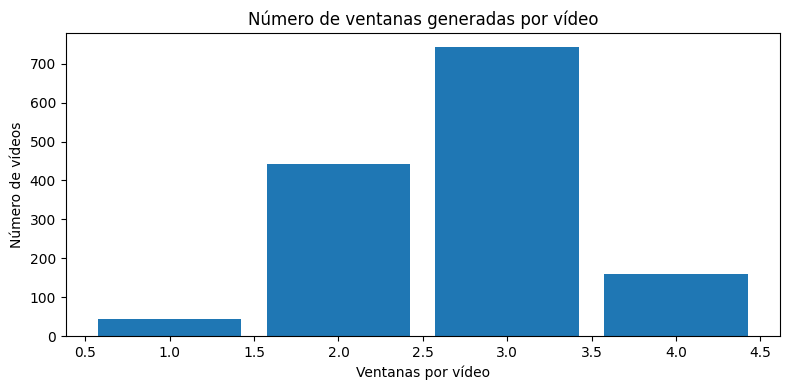

In [30]:
if not df.empty:
    plt.figure(figsize=(8, 4))
    plt.hist(per_video["n_windows"],
             bins=range(1, int(per_video["n_windows"].max()) + 2),
             align="left", rwidth=0.85)
    plt.title("Número de ventanas generadas por vídeo")
    plt.xlabel("Ventanas por vídeo")
    plt.ylabel("Número de vídeos")
    plt.tight_layout()
    plt.show()

## 7. Distribución de escenarios / descripciones

Audita si train y validation tienen tipos de accidente similares y si alguna categoría domina.

In [31]:
if not df.empty:
    scenario_counts = df["description"].value_counts().reset_index()
    scenario_counts.columns = ["description", "samples"]
    print(f"Descripciones únicas: {len(scenario_counts)}")
    display(scenario_counts.head(25))

Descripciones únicas: 93


,description,samples
0,a motorbike crosses the road,480
1,a vehicle changes lanes with the same directio...,336
2,lead vehicle stops,257
3,a vehicle crosses the road,244
4,a motorbike is out of control,202
5,a vehicle is out of control,201
6,a pedestrian crosses the road,148
7,a vehicle overtakes,125
8,a vehicle changes lanes with the same directio...,125
9,lead vehicle stops,99


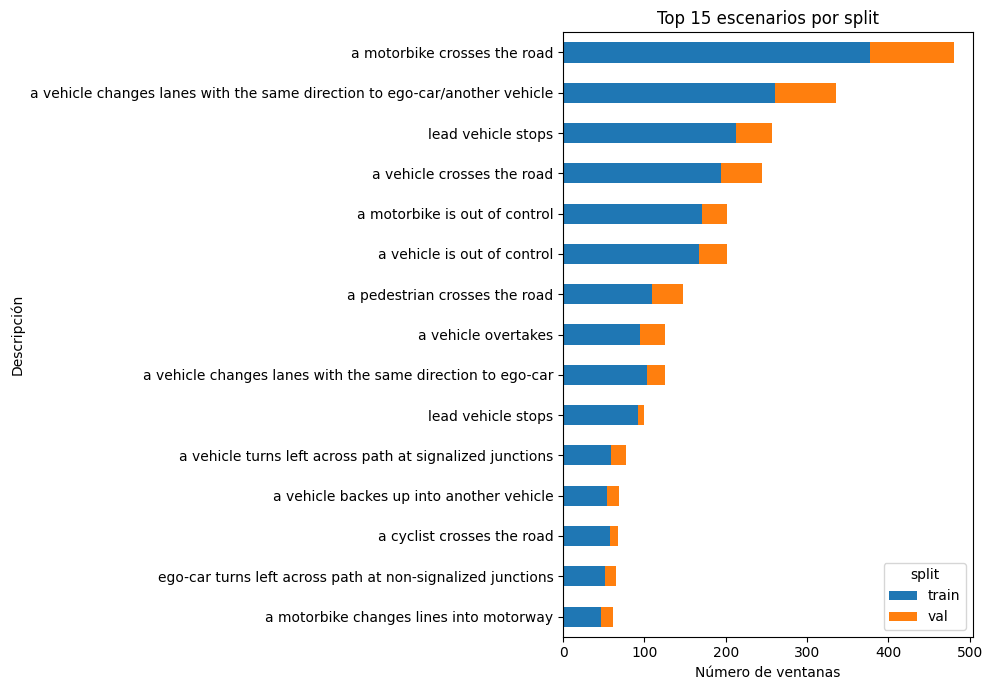

In [32]:
if not df.empty:
    TOP_N = 15
    top_scenarios = df["description"].value_counts().head(TOP_N).index
    plot_df = df[df["description"].isin(top_scenarios)]
    ct = pd.crosstab(plot_df["description"], plot_df["split"])
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

    ax = ct.plot(kind="barh", stacked=True, figsize=(10, 7))
    ax.set_title(f"Top {TOP_N} escenarios por split")
    ax.set_xlabel("Número de ventanas")
    ax.set_ylabel("Descripción")
    plt.tight_layout()
    plt.show()

In [33]:
if not df.empty and not train_df.empty and not val_df.empty:
    train_scen = set(train_df["description"])
    val_scen = set(val_df["description"])
    only_train = sorted(train_scen - val_scen)
    only_val = sorted(val_scen - train_scen)

    scenario_split_summary = pd.DataFrame([
        {"métrica": "escenarios únicos train", "valor": len(train_scen)},
        {"métrica": "escenarios únicos val", "valor": len(val_scen)},
        {"métrica": "escenarios compartidos", "valor": len(train_scen & val_scen)},
        {"métrica": "escenarios solo train", "valor": len(only_train)},
        {"métrica": "escenarios solo val", "valor": len(only_val)},
    ])
    display(scenario_split_summary)

    if only_val:
        print(f"\n⚠️  Hay {len(only_val)} escenarios que aparecen SOLO en validation:")
        for s in only_val[:20]:
            print("  -", s)

,métrica,valor
0,escenarios únicos train,86
1,escenarios únicos val,63
2,escenarios compartidos,56
3,escenarios solo train,30
4,escenarios solo val,7



⚠️  Hay 7 escenarios que aparecen SOLO en validation:
  - a cyclist turns right across path at signalized junctions
  - a vehicle changes lanes - same direction
  - a vehicle makes a dodge action
  - a vehicle turns on a road with the opposite direction to
  - ego-car goes straight at non-signalized junctions
  - ego-car turns right across path at signalized junctions
  - lead cyclist stops


In [34]:
if not df.empty:
    scenario_label = pd.crosstab(df["description"], df["label"])
    scenario_label.columns = ["label_0_far", "label_1_near"]
    scenario_label["total"] = scenario_label.sum(axis=1)
    scenario_label["positive_rate"] = scenario_label["label_1_near"] / scenario_label["total"]
    display(scenario_label.sort_values("total", ascending=False).head(25))

,label_0_far,label_1_near,total,positive_rate
description,,,,
a motorbike crosses the road,254,226,480,0.470833
a vehicle changes lanes with the same direction to ego-car/another vehicle,188,148,336,0.440476
lead vehicle stops,141,116,257,0.451362
a vehicle crosses the road,135,109,244,0.446721
a motorbike is out of control,108,94,202,0.465347
a vehicle is out of control,113,88,201,0.437811
a pedestrian crosses the road,78,70,148,0.472973
a vehicle overtakes,70,55,125,0.440000
a vehicle changes lanes with the same direction to ego-car,75,50,125,0.400000


## 8. Distribución por `group_id`

Los IDs tienen forma `grupo/vídeo`, por ejemplo `49/022`. Este análisis ayuda a detectar sesgos por grupo/carpeta.

In [35]:
if not df.empty:
    group_summary = df.groupby("group_id").agg(
        samples=("clip_id", "count"),
        videos=("video_id", "nunique"),
        positive_rate=("label", "mean"),
        mean_gap=("gap_to_toa", "mean"),
    ).sort_values("samples", ascending=False)
    display(group_summary.head(30))

    ct_group_split = pd.crosstab(df["group_id"], df["split"])
    ct_group_split["total"] = ct_group_split.sum(axis=1)
    display(ct_group_split.sort_values("total", ascending=False).head(30))

,samples,videos,positive_rate,mean_gap
group_id,,,,
11,516,182,0.434109,68.565891
5,369,131,0.463415,69.289973
10,353,123,0.427762,72.906516
43,326,127,0.457055,64.346626
6,280,100,0.460714,68.728571
50,255,98,0.478431,63.380392
48,162,59,0.462963,68.049383
37,133,53,0.473684,57.248120
8,131,48,0.419847,54.282443


split,train,val,total
group_id,,,
11,448,68,516
5,289,80,369
10,272,81,353
43,278,48,326
6,243,37,280
50,201,54,255
48,109,53,162
37,108,25,133
8,114,17,131


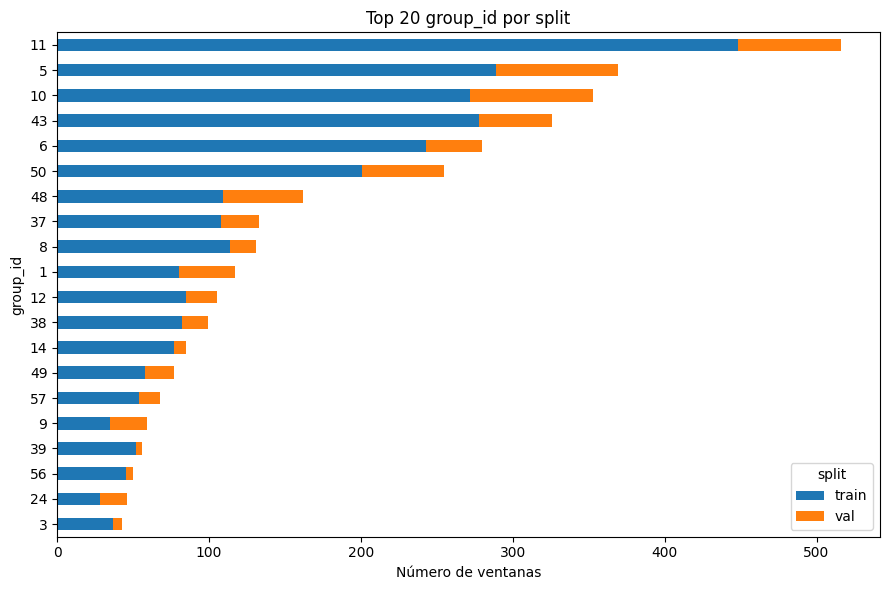

In [36]:
if not df.empty:
    TOP_GROUPS = 20
    top_groups = df["group_id"].value_counts().head(TOP_GROUPS).index
    ct = pd.crosstab(df[df["group_id"].isin(top_groups)]["group_id"],
                     df[df["group_id"].isin(top_groups)]["split"])
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]
    ax = ct.plot(kind="barh", stacked=True, figsize=(9, 6))
    ax.set_title(f"Top {TOP_GROUPS} group_id por split")
    ax.set_xlabel("Número de ventanas")
    ax.set_ylabel("group_id")
    plt.tight_layout()
    plt.show()

## 9. Solapamiento temporal entre ventanas

Con `window_len=64` y `stride=16`, el solapamiento esperado entre ventanas
consecutivas del mismo vídeo es aproximadamente 75% (48 frames compartidos).

Esto refuerza que el split por vídeo sea obligatorio.

In [37]:
if not df.empty:
    df_sorted = df.sort_values(["video_id", "start", "end"]).copy()
    df_sorted["start_diff"] = df_sorted.groupby("video_id")["start"].diff()
    df_sorted["prev_end"] = df_sorted.groupby("video_id")["end"].shift(1)
    df_sorted["overlap_frames_with_prev"] = (df_sorted["prev_end"] - df_sorted["start"] + 1).clip(lower=0)
    df_sorted["overlap_ratio_with_prev"] = df_sorted["overlap_frames_with_prev"] / df_sorted["window_len"]

    display(df_sorted["start_diff"].dropna().describe().to_frame("start_diff"))
    display(df_sorted["overlap_ratio_with_prev"].dropna().describe().to_frame("overlap_ratio"))
    print("Start diffs más frecuentes (debe haber un pico en stride={}):".format(STRIDE_EXPECTED))
    display(df_sorted["start_diff"].value_counts().head(10).to_frame("count"))

,start_diff
count,2402.000000
mean,59.357202
std,40.959420
min,16.000000
25%,16.000000
50%,48.000000
75%,96.000000
max,320.000000


,overlap_ratio
count,2402.000000
mean,0.325354
std,0.334788
min,0.000000
25%,0.000000
50%,0.250000
75%,0.750000
max,0.750000


Start diffs más frecuentes (debe haber un pico en stride=16):


,count
16.0,780
96.0,471
32.0,284
48.0,218
112.0,196
64.0,168
128.0,115
80.0,110
144.0,53
192.0,6


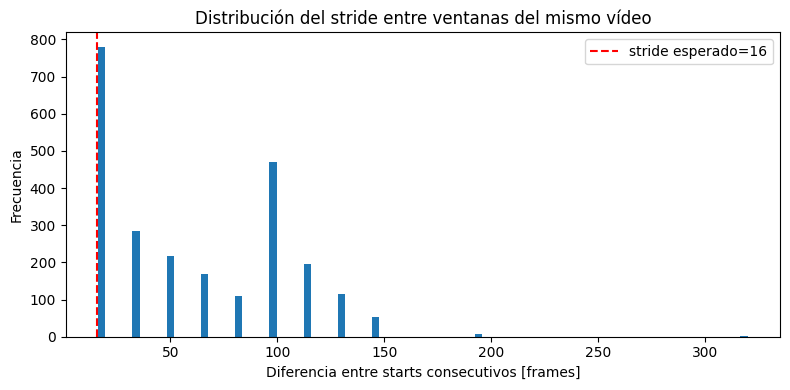

In [38]:
if not df.empty:
    plt.figure(figsize=(8, 4))
    vals = df_sorted["start_diff"].dropna()
    if len(vals):
        plt.hist(vals, bins=range(int(vals.min()), int(vals.max()) + 2, 4), rwidth=0.85)
    plt.axvline(STRIDE_EXPECTED, linestyle="--", color="red",
                label=f"stride esperado={STRIDE_EXPECTED}")
    plt.title("Distribución del stride entre ventanas del mismo vídeo")
    plt.xlabel("Diferencia entre starts consecutivos [frames]")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 10. Qué ve realmente el modelo X3D-S + GRU

Ventana original: 64 frames.

Entrada al modelo: 16 frames muestreados uniformemente.

X3D-S internamente: 4 subclips de 13 frames si `subclip_len=13` y `stride=1`.

In [39]:
def selected_frames_for_model(start, end, num_frames=NUM_FRAMES_MODEL):
    return np.round(np.linspace(start, end, num_frames)).astype(int)

if not df.empty:
    sampled = []
    for _, row in df.iterrows():
        selected = selected_frames_for_model(row["start"], row["end"])
        diffs = np.diff(selected)
        n_subclips = max(0, 1 + (len(selected) - X3D_SUBCLIP_LEN) // X3D_SUBCLIP_STRIDE)
        # Para negativos absolutos (toa=0), last_selected_before_toa no aplica
        last_before_toa = bool(selected[-1] < row["toa"]) if row["toa"] > 0 else None
        sampled.append({
            "clip_id": row["clip_id"],
            "selected_first": int(selected[0]),
            "selected_last": int(selected[-1]),
            "selected_min_diff": int(diffs.min()) if len(diffs) else np.nan,
            "selected_max_diff": int(diffs.max()) if len(diffs) else np.nan,
            "selected_mean_diff": float(diffs.mean()) if len(diffs) else np.nan,
            "n_selected_frames": len(selected),
            "n_x3d_subclips": n_subclips,
            "last_selected_before_toa": last_before_toa,
        })

    sampled_df = pd.DataFrame(sampled)
    df_model = df.merge(sampled_df, on="clip_id", how="left")

    display(df_model[["n_selected_frames", "selected_mean_diff", "selected_min_diff",
                      "selected_max_diff", "n_x3d_subclips", "last_selected_before_toa"]]
                    .describe(include="all"))

    # Solo verificar pre-TOA en muestras con toa > 0
    df_pre_model = df_model[df_model["toa"] > 0]
    bad_model_toa = df_pre_model[df_pre_model["last_selected_before_toa"] == False]
    print(f"\nFilas pre-TOA donde el último frame seleccionado NO es pre-TOA: {len(bad_model_toa)}")
    if len(bad_model_toa):
        display(bad_model_toa.head(10))

,n_selected_frames,selected_mean_diff,selected_min_diff,selected_max_diff,n_x3d_subclips,last_selected_before_toa
count,3789.0,3.789000e+03,3789.0,3789.0,3789.0,3756
unique,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,NaN,3756
mean,16.0,4.200000e+00,4.0,5.0,4.0,NaN
std,0.0,8.882956e-16,0.0,0.0,0.0,NaN
min,16.0,4.200000e+00,4.0,5.0,4.0,NaN
25%,16.0,4.200000e+00,4.0,5.0,4.0,NaN
50%,16.0,4.200000e+00,4.0,5.0,4.0,NaN
75%,16.0,4.200000e+00,4.0,5.0,4.0,NaN



Filas pre-TOA donde el último frame seleccionado NO es pre-TOA: 0


In [40]:
if not df.empty:
    example_cols = ["video_id", "label", "start", "end", "toa", "gap_to_toa", "description"]
    examples = df.sample(min(5, len(df)), random_state=42)[example_cols].copy()
    examples["selected_frames"] = examples.apply(
        lambda r: selected_frames_for_model(r["start"], r["end"]).tolist(), axis=1)
    display(examples)

,video_id,label,start,end,toa,gap_to_toa,description,selected_frames
1580,56/012,0,33,96,217,121,a vehicle turns left across path at signalized...,"[33, 37, 41, 46, 50, 54, 58, 62, 67, 71, 75, 7..."
2257,3/011,0,1,64,170,106,a cyclist crosses the road,"[1, 5, 9, 14, 18, 22, 26, 30, 35, 39, 43, 47, ..."
263,1/045,0,1,64,0,-64,a pedestrian crosses the road,"[1, 5, 9, 14, 18, 22, 26, 30, 35, 39, 43, 47, ..."
1837,48/042,0,1,64,150,86,a vehicle changes lanes with the same directio...,"[1, 5, 9, 14, 18, 22, 26, 30, 35, 39, 43, 47, ..."
3653,12/024,0,49,112,218,106,a vehicle overtakes,"[49, 53, 57, 62, 66, 70, 74, 78, 83, 87, 91, 9..."


## 11. Bins de gap para evaluación posterior del modelo

Esto no entrena el modelo, pero prepara un análisis muy útil:

> ¿La probabilidad media de riesgo sube al acercarse al TOA?

In [41]:
if not df.empty:
    gap_bins = [-np.inf, 0, POSITIVE_HORIZON, NEGATIVE_MIN_DISTANCE - 1,
                NEGATIVE_MAX_DISTANCE, np.inf]
    gap_labels = [
        "absolutos / inválido",
        f"1-{POSITIVE_HORIZON} (positivo)",
        f"{POSITIVE_HORIZON+1}-{NEGATIVE_MIN_DISTANCE-1} (zona gris/rescate)",
        f"{NEGATIVE_MIN_DISTANCE}-{NEGATIVE_MAX_DISTANCE} (negativo estricto)",
        f">{NEGATIVE_MAX_DISTANCE}",
    ]
    df["gap_bin"] = pd.cut(df["gap_to_toa"], bins=gap_bins, labels=gap_labels, right=True)

    gap_bin_table = pd.crosstab(df["gap_bin"], df["label"], dropna=False)
    gap_bin_table.columns = ["label_0_far", "label_1_near"]
    gap_bin_table["total"] = gap_bin_table.sum(axis=1)
    display(gap_bin_table)

,label_0_far,label_1_near,total
gap_bin,,,
absolutos / inválido,33,0,33
1-20 (positivo),0,1707,1707
21-100 (zona gris/rescate),495,0,495
101-180 (negativo estricto),1554,0,1554
>180,0,0,0


## 12. Auditar `training_balanced.txt` si existe

Verifica que el archivo intermedio antes del split tiene las mismas
propiedades que los splits finales (debe ser exactamente train + val).

In [42]:
if BALANCED_TXT.exists():
    balanced_df = load_txt(BALANCED_TXT, "balanced_total")
    print(f"training_balanced.txt: {len(balanced_df)} líneas (esperado: {len(df)})")
    if len(balanced_df) != len(df):
        print(f"⚠️  Diferencia: {len(balanced_df) - len(df)} líneas")
    display(split_summary(balanced_df))

    bal_pre = balanced_df[~balanced_df["is_absolute_negative"]]
    balanced_checks = pd.DataFrame([
        {"check": "end >= TOA (en pre-TOA)",
         "bad_rows": len(bal_pre[bal_pre["end"] >= bal_pre["toa"]])},
        {"check": f"label 1 fuera de gap [1, {POSITIVE_HORIZON}]",
         "bad_rows": len(bal_pre[(bal_pre["label"] == 1) & ~bal_pre["gap_to_toa"].between(1, POSITIVE_HORIZON)])},
        {"check": f"label 0 fuera de gap [{NEGATIVE_MIN_DISTANCE}, {NEGATIVE_MAX_DISTANCE}] (excl. rescate)",
         "bad_rows": len(bal_pre[(bal_pre["label"] == 0) & ~bal_pre["gap_to_toa"].between(NEGATIVE_MIN_DISTANCE, NEGATIVE_MAX_DISTANCE)])},
    ])
    balanced_checks["status"] = np.where(balanced_checks["bad_rows"] == 0, "OK", "INFO (rescate)")
    display(balanced_checks)
else:
    print("No existe BALANCED_TXT. Omitido.")

training_balanced.txt: 3789 líneas (esperado: 3789)


,split,samples,unique_videos,unique_groups,label_0_far,label_1_near,positive_rate,abs_negatives,mean_gap_pre_toa,median_gap_pre_toa
0,balanced_total,3789,1387,51,2082,1707,0.450515,33,68.469116,56.0
1,total,3789,1387,51,2082,1707,0.450515,33,68.469116,56.0


,check,bad_rows,status
0,end >= TOA (en pre-TOA),0,OK
1,"label 1 fuera de gap [1, 20]",0,OK
2,"label 0 fuera de gap [101, 180] (excl. rescate)",495,INFO (rescate)


## 13. Opcional: EDA visual de frames

Activa `RGB_ROOT` para mostrar imágenes. Recomendación para la memoria:
mostrar para un mismo vídeo una ventana `label=0` y una ventana `label=1`
con primer frame, frame central y último frame.

In [43]:
try:
    from PIL import Image
except Exception:
    Image = None


def find_frame_path(rgb_root, video_id, frame_idx):
    if rgb_root is None:
        return None
    video_dir = Path(rgb_root) / video_id
    candidates = []
    for ext in ["png", "jpg", "jpeg"]:
        candidates.extend([
            video_dir / f"{frame_idx:04d}.{ext}",
            video_dir / f"{frame_idx:05d}.{ext}",
            video_dir / f"{frame_idx:06d}.{ext}",
            video_dir / f"{frame_idx}.{ext}",
        ])
    for p in candidates:
        if p.exists():
            return p
    return None


def plot_window_triplet(row, rgb_root):
    if Image is None:
        print("PIL no está disponible.")
        return
    frames = [row["start"], int(round((row["start"] + row["end"]) / 2)), row["end"]]
    titles = ["start", "middle", "end"]
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
    for ax, fr, title in zip(axes, frames, titles):
        p = find_frame_path(rgb_root, row["video_id"], fr)
        ax.axis("off")
        ax.set_title(f"{title}\nframe {fr}")
        if p is None:
            ax.text(0.5, 0.5, "frame no encontrado", ha="center", va="center")
        else:
            img = Image.open(p).convert("RGB")
            ax.imshow(img)
    fig.suptitle(f"{row['video_id']} | label={row['label']} | gap={row['gap_to_toa']} | {row['description']}")
    plt.tight_layout()
    plt.show()


if RGB_ROOT is None:
    print("RGB_ROOT no configurado. Define RGB_ROOT para activar visualización de frames.")
elif df.empty:
    print("df vacío. Saltando visualización.")
else:
    RGB_ROOT_P = Path(RGB_ROOT)
    both = per_video[per_video["class_pattern"] == "ambas clases"]
    if both.empty:
        print("No hay vídeos con ambas clases en el dataframe actual.")
    else:
        vid = both.iloc[0]["video_id"]
        rows_v = df[df["video_id"] == vid].sort_values(["label", "gap_to_toa"])
        display(rows_v[["video_id", "label", "start", "end", "toa", "gap_to_toa", "description"]])
        for _, row in rows_v.iterrows():
            plot_window_triplet(row, RGB_ROOT_P)

RGB_ROOT no configurado. Define RGB_ROOT para activar visualización de frames.


## 14. Exportar tablas para la memoria

In [44]:
OUTPUT_DIR = Path("/data-fast/data-server/vlopezmo/model/training/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not df.empty:
    summary.to_csv(OUTPUT_DIR / "summary_splits.csv", index=False)
    checks_df.to_csv(OUTPUT_DIR / "temporal_integrity_checks.csv", index=False)
    stats_gap.to_csv(OUTPUT_DIR / "gap_stats_by_split_label.csv", index=False)
    per_video.to_csv(OUTPUT_DIR / "per_video_summary.csv", index=False)
    scenario_counts.to_csv(OUTPUT_DIR / "scenario_counts.csv", index=False)
    scenario_label.to_csv(OUTPUT_DIR / "scenario_label_distribution.csv")
    group_summary.to_csv(OUTPUT_DIR / "group_summary.csv")
    retention_df.to_csv(OUTPUT_DIR / "pipeline_retention.csv", index=False)
    if 'hp_check' in dir():
        hp_check.to_csv(OUTPUT_DIR / "hyperparameter_justification.csv", index=False)
    if 'fallback_summary' in dir():
        fallback_summary.to_csv(OUTPUT_DIR / "fallback_audit.csv", index=False)

    print("Tablas exportadas en:", OUTPUT_DIR)
    for p in sorted(OUTPUT_DIR.glob("*.csv")):
        print(" -", p.name)
else:
    print("df vacío. No se exporta nada.")

Tablas exportadas en: /data-fast/data-server/vlopezmo/model/training/eda_outputs
 - fallback_audit.csv
 - gap_stats_by_split_label.csv
 - group_summary.csv
 - hyperparameter_justification.csv
 - per_video_summary.csv
 - pipeline_retention.csv
 - scenario_counts.csv
 - scenario_label_distribution.csv
 - summary_splits.csv
 - temporal_integrity_checks.csv


## 15. Conclusiones automáticas para la memoria

Resumen final que cubre tanto la auditoría del pipeline (Parte 1)
como la auditoría de los splits (Parte 2). Úsalo como borrador
para la sección "Construcción del dataset" del TFG.

In [45]:
if not df.empty:
    all_temporal_ok = (
        len(bad_post_toa) == 0 and
        len(bad_pos) == 0 and
        len(df_pre[(df_pre["label"] == 1) & df_pre["gap_to_toa"].between(POSITIVE_HORIZON+1, NEGATIVE_MIN_DISTANCE-1)]) == 0
    )
    leakage_ok = len(overlap_videos) == 0
    window_len_ok = len(bad_len) == 0
    no_shortcut = (trivial_auc is not None and trivial_auc < 0.55)

    print("=" * 65)
    print("CONCLUSIONES DEL EDA — PARTE 1 (PIPELINE)")
    print("=" * 65)
    print()
    if n_excel_total:
        print(f"📊 Origen: {n_excel_total} vídeos en DADA2000 → {n_balanced_videos} vídeos en splits "
              f"({100*n_balanced_videos/n_excel_total:.1f}% de retención)")
    if not df_excel.empty:
        print(f"📊 El {100*n_can_pos/n_toa_total:.1f}% de vídeos con TOA permite generar positivos.")
        print(f"📊 El {100*n_need_rescue/n_toa_total:.1f}% requiere mecanismo de rescate (gray_zone reducida).")
    if 'n_fallback' in dir():
        print(f"📊 {n_fallback} muestras ({100*n_fallback/len(df):.1f}% del total) provienen del fallback start=1.")
    if trivial_auc is not None:
        print(f"📊 AUC del modelo trivial (start → label): {trivial_auc:.4f} (baseline=0.5)")
    print()

    print("=" * 65)
    print("CONCLUSIONES DEL EDA — PARTE 2 (SPLITS)")
    print("=" * 65)
    print()

    if all_temporal_ok:
        print("✅ Todas las ventanas pre-TOA respetan los rangos de label esperados.")
    else:
        print("⚠️  Hay inconsistencias temporales. Revisa temporal_integrity_checks.csv.")

    if leakage_ok:
        print("✅ No hay solapamiento de video_id entre train y validation.")
    else:
        print("⚠️  Hay vídeos compartidos entre train y validation. INVALIDA la evaluación.")

    if window_len_ok:
        print(f"✅ Todas las ventanas tienen longitud esperada de {WINDOW_LEN_EXPECTED} frames.")
    else:
        print("⚠️  Hay ventanas con longitud distinta a la esperada.")

    if trivial_auc is not None:
        if no_shortcut:
            print(f"✅ Sin atajos espurios start↔label (AUC trivial = {trivial_auc:.3f} < 0.55).")
        elif trivial_auc < 0.65:
            print(f"⚠️  Correlación moderada start↔label (AUC trivial = {trivial_auc:.3f}). Reportar.")
        else:
            print(f"❌ Correlación FUERTE start↔label (AUC trivial = {trivial_auc:.3f}). REVISAR.")
    print()

    print(f"Muestras totales: {len(df)}")
    print(f"Vídeos únicos: {df['video_id'].nunique()}")
    print(f"Tasa positiva global: {(df['label'] == 1).mean():.3f}")
    df_pre_final = df[~df['is_absolute_negative']]
    print(f"Gap medio label 1: {df_pre_final[df_pre_final['label'] == 1]['gap_to_toa'].mean():.2f} frames")
    print(f"Gap medio label 0 (sin absolutos): {df_pre_final[df_pre_final['label'] == 0]['gap_to_toa'].mean():.2f} frames")

    print()
    print("=" * 65)
    print("FRASE SUGERIDA PARA LA MEMORIA:")
    print("=" * 65)
    print()
    print("El dataset final se formula como una tarea de anticipación de riesgo a")
    print("nivel de ventana temporal a partir de DADA2000. De los", n_excel_total, "vídeos")
    print("originales del Excel anotado, se generan ventanas deslizantes de longitud")
    print(f"{WINDOW_LEN_EXPECTED} frames y stride {STRIDE_EXPECTED}; las muestras positivas")
    print(f"corresponden a ventanas con gap_to_TOA ∈ [1, {POSITIVE_HORIZON}] frames y las negativas")
    print(f"a gap ∈ [{NEGATIVE_MIN_DISTANCE}, {NEGATIVE_MAX_DISTANCE}] frames, con una zona gris descartada para")
    print("forzar separación temporal entre clases. El split se realiza a nivel de")
    print(f"video_id (ratio 80/20), garantizando ausencia de fuga. Tras la auditoría,")
    if no_shortcut:
        print(f"se verificó que ningún clasificador trivial puede separar las clases")
        print(f"a partir del frame inicial (AUC = {trivial_auc:.3f}), descartando atajos")
        print(f"espurios derivados del balanceo.")
    else:
        print(f"el balanceo presenta una correlación start↔label de AUC={trivial_auc:.3f},")
        print(f"que se reporta como limitación del trabajo.")
else:
    print("df vacío. No se pueden generar conclusiones.")

CONCLUSIONES DEL EDA — PARTE 1 (PIPELINE)

📊 Origen: 1962 vídeos en DADA2000 → 1387 vídeos en splits (70.7% de retención)
📊 El 88.3% de vídeos con TOA permite generar positivos.
📊 El 38.1% requiere mecanismo de rescate (gray_zone reducida).
📊 860 muestras (22.7% del total) provienen del fallback start=1.
📊 AUC del modelo trivial (start → label): 0.8260 (baseline=0.5)

CONCLUSIONES DEL EDA — PARTE 2 (SPLITS)

✅ Todas las ventanas pre-TOA respetan los rangos de label esperados.
✅ No hay solapamiento de video_id entre train y validation.
✅ Todas las ventanas tienen longitud esperada de 64 frames.
❌ Correlación FUERTE start↔label (AUC trivial = 0.826). REVISAR.

Muestras totales: 3789
Vídeos únicos: 1387
Tasa positiva global: 0.451
Gap medio label 1: 10.61 frames
Gap medio label 0 (sin absolutos): 116.67 frames

FRASE SUGERIDA PARA LA MEMORIA:

El dataset final se formula como una tarea de anticipación de riesgo a
nivel de ventana temporal a partir de DADA2000. De los 1962 vídeos
originale